In [5]:
from google.colab import files
import pandas as pd
import io

# Загружаем файл с компьютера
print("Нажми 'Выбрать файл' и загрузи reviews.csv")
uploaded = files.upload()

# Читаем файл
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='utf-8', sep='\t')
print(f"Файл {filename} загружен успешно!")
print(f"Всего отзывов: {len(df)}")
df.head()

Нажми 'Выбрать файл' и загрузи reviews.csv


Saving reviews.csv to reviews (1).csv
Файл reviews (1).csv загружен успешно!
Всего отзывов: 90000


,review,sentiment
0,качество плохое пошив ужасный (горловина напер...,negative
1,"Товар отдали другому человеку, я не получила п...",negative
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"Кофточка голая синтетика, носить не возможно.",negative


In [6]:
# Установка библиотек (в Colab нужно только pymorphy3, остальное уже есть)
!pip install pymorphy3

# Импорты
import numpy as np
import pandas as pd
import re
import string
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import pymorphy3

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

# Скачиваем ресурсы NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

print("Все библиотеки установлены!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 62.3 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Все библиотеки установлены!


In [7]:
# Функция очистки текста
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Удаляем эмодзи
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"
                           u"\U0001F300-\U0001F5FF"
                           u"\U0001F680-\U0001F6FF"
                           u"\U0001F1E0-\U0001F1FF"
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    return text

df['clean_text'] = df['review'].apply(clean_text)
print("Текст очищен")

Текст очищен


In [8]:
# Стоп-слова
stop_words = set(stopwords.words('russian'))

def remove_stopwords(text):
    words = text.split()
    return ' '.join([w for w in words if w not in stop_words])

df['clean_text'] = df['clean_text'].apply(remove_stopwords)
print("Стоп-слова удалены")

# Токенизация
df['tokens'] = df['clean_text'].apply(word_tokenize)
print("Токенизация готова")

Стоп-слова удалены
Токенизация готова


In [9]:
# Лемматизация
morph = pymorphy3.MorphAnalyzer()

def lemmatize(token_list):
    if not isinstance(token_list, list):
        return token_list
    return [morph.parse(word)[0].normal_form for word in token_list]

df['lemmas'] = df['tokens'].apply(lemmatize)
print("Лемматизация готова")
print("Пример:", df['lemmas'].iloc[0][:10])

Лемматизация готова
Пример: ['качество', 'плохой', 'пошив', 'ужасный', 'горловина', 'наперекос', 'фото', 'соответствовать', 'ткань', 'ужасный']


In [10]:
# Векторизация
df['text_for_vec'] = df['lemmas'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=0.001, max_df=0.99)
X = vectorizer.fit_transform(df['text_for_vec'])

print(f"Размер матрицы: {X.shape}")
print(f"Количество признаков: {len(vectorizer.get_feature_names_out())}")

Размер матрицы: (90000, 2079)
Количество признаков: 2079


In [11]:
# K-Means
N_CLUSTERS = 3

kmeans = KMeans(n_clusters=N_CLUSTERS, max_iter=10000, n_init=100, random_state=42)
kmeans.fit(X)

df['cluster'] = kmeans.labels_

print("Распределение отзывов по кластерам:")
print(Counter(df['cluster']))

Распределение отзывов по кластерам:
Counter({2: 56163, 1: 21536, 0: 12301})


In [13]:
# Функция для ключевых слов
def get_cluster_keywords(cluster_num, top_n=30):
    feature_names = vectorizer.get_feature_names_out()
    sorted_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
    keywords = [feature_names[idx] for idx in sorted_centroids[cluster_num, :top_n]]
    return keywords

# Сбор примеров отзывов
cluster_samples = {}
for clust in range(N_CLUSTERS):
    samples = df[df['cluster'] == clust]['review'].head(20).tolist()
    cluster_samples[clust] = samples

In [14]:
# Вывод результатов
for clust in range(N_CLUSTERS):
    print(f"\n{'='*60}")
    print(f"КЛАСТЕР №{clust+1} (размер: {sum(df['cluster'] == clust)} отзывов)")
    print(f"{'='*60}")

    keywords = get_cluster_keywords(clust)
    print("\nКлючевые слова:")
    print(', '.join(keywords[:15]))

    print("\nПримеры отзывов:")
    for i, rev in enumerate(cluster_samples[clust][:5], 1):
        if len(str(rev)) > 150:
            print(f"{i}. {str(rev)[:150]}...")
        else:
            print(f"{i}. {rev}")


КЛАСТЕР №1 (размер: 12301 отзывов)

Ключевые слова:
продавец, деньга, вернуть, товар, прийти, спор, деньга вернуть, заказ, товар прийти, открыть, вернуть деньга, открыть спор, месяц, получить, очень

Примеры отзывов:
1. Товар отдали другому человеку, я не получила посылку. Ладно хоть деньги вернули.
2. товар не пришел, продавец продлил защиту без моего согласия. от продавца одни обещания
3. товар застрял во Внуково. видимо каряво написали адрес. деньги не вернули!!!!
4. Заказывала фиолетовую кофту размер XL, пришла очень маленькая кофта по длине 53 см и по груди тоже-детская разм. меньше чем S. Очень расстроилась, по ...
5. заказ не пришёл. ждала с мая. спор открывать не буду, считаю это ниже моего достоинства. Пусть будет на совести продавца. магазин заигнорю

КЛАСТЕР №2 (размер: 21536 отзывов)

Ключевые слова:
размер, очень, продавец, качество, подойти, маленький, заказать, прийти, хороший, соответствовать, рост, заказывать, это, доставка, ткань

Примеры отзывов:
1. заказала размер 

In [15]:
# Интерпретация
interpretation = {
    0: "Кластер 0: Проблемы с размером. Отзывы жалуются на несоответствие размерной сетке, вещи малы/велики.",
    1: "Кластер 1: Проблемы с доставкой и возвратом. Пользователи не получили товар, жалуются на возврат денег.",
    2: "Кластер 2: Общее качество товара. Отзывы о качестве ткани, пошиве, соответствии фото."
}

print("\nИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:")
for clust in range(N_CLUSTERS):
    print(interpretation[clust])


ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:
Кластер 0: Проблемы с размером. Отзывы жалуются на несоответствие размерной сетке, вещи малы/велики.
Кластер 1: Проблемы с доставкой и возвратом. Пользователи не получили товар, жалуются на возврат денег.
Кластер 2: Общее качество товара. Отзывы о качестве ткани, пошиве, соответствии фото.


) missing from font(s) DejaVu Sans.
  plt.tight_layout()
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


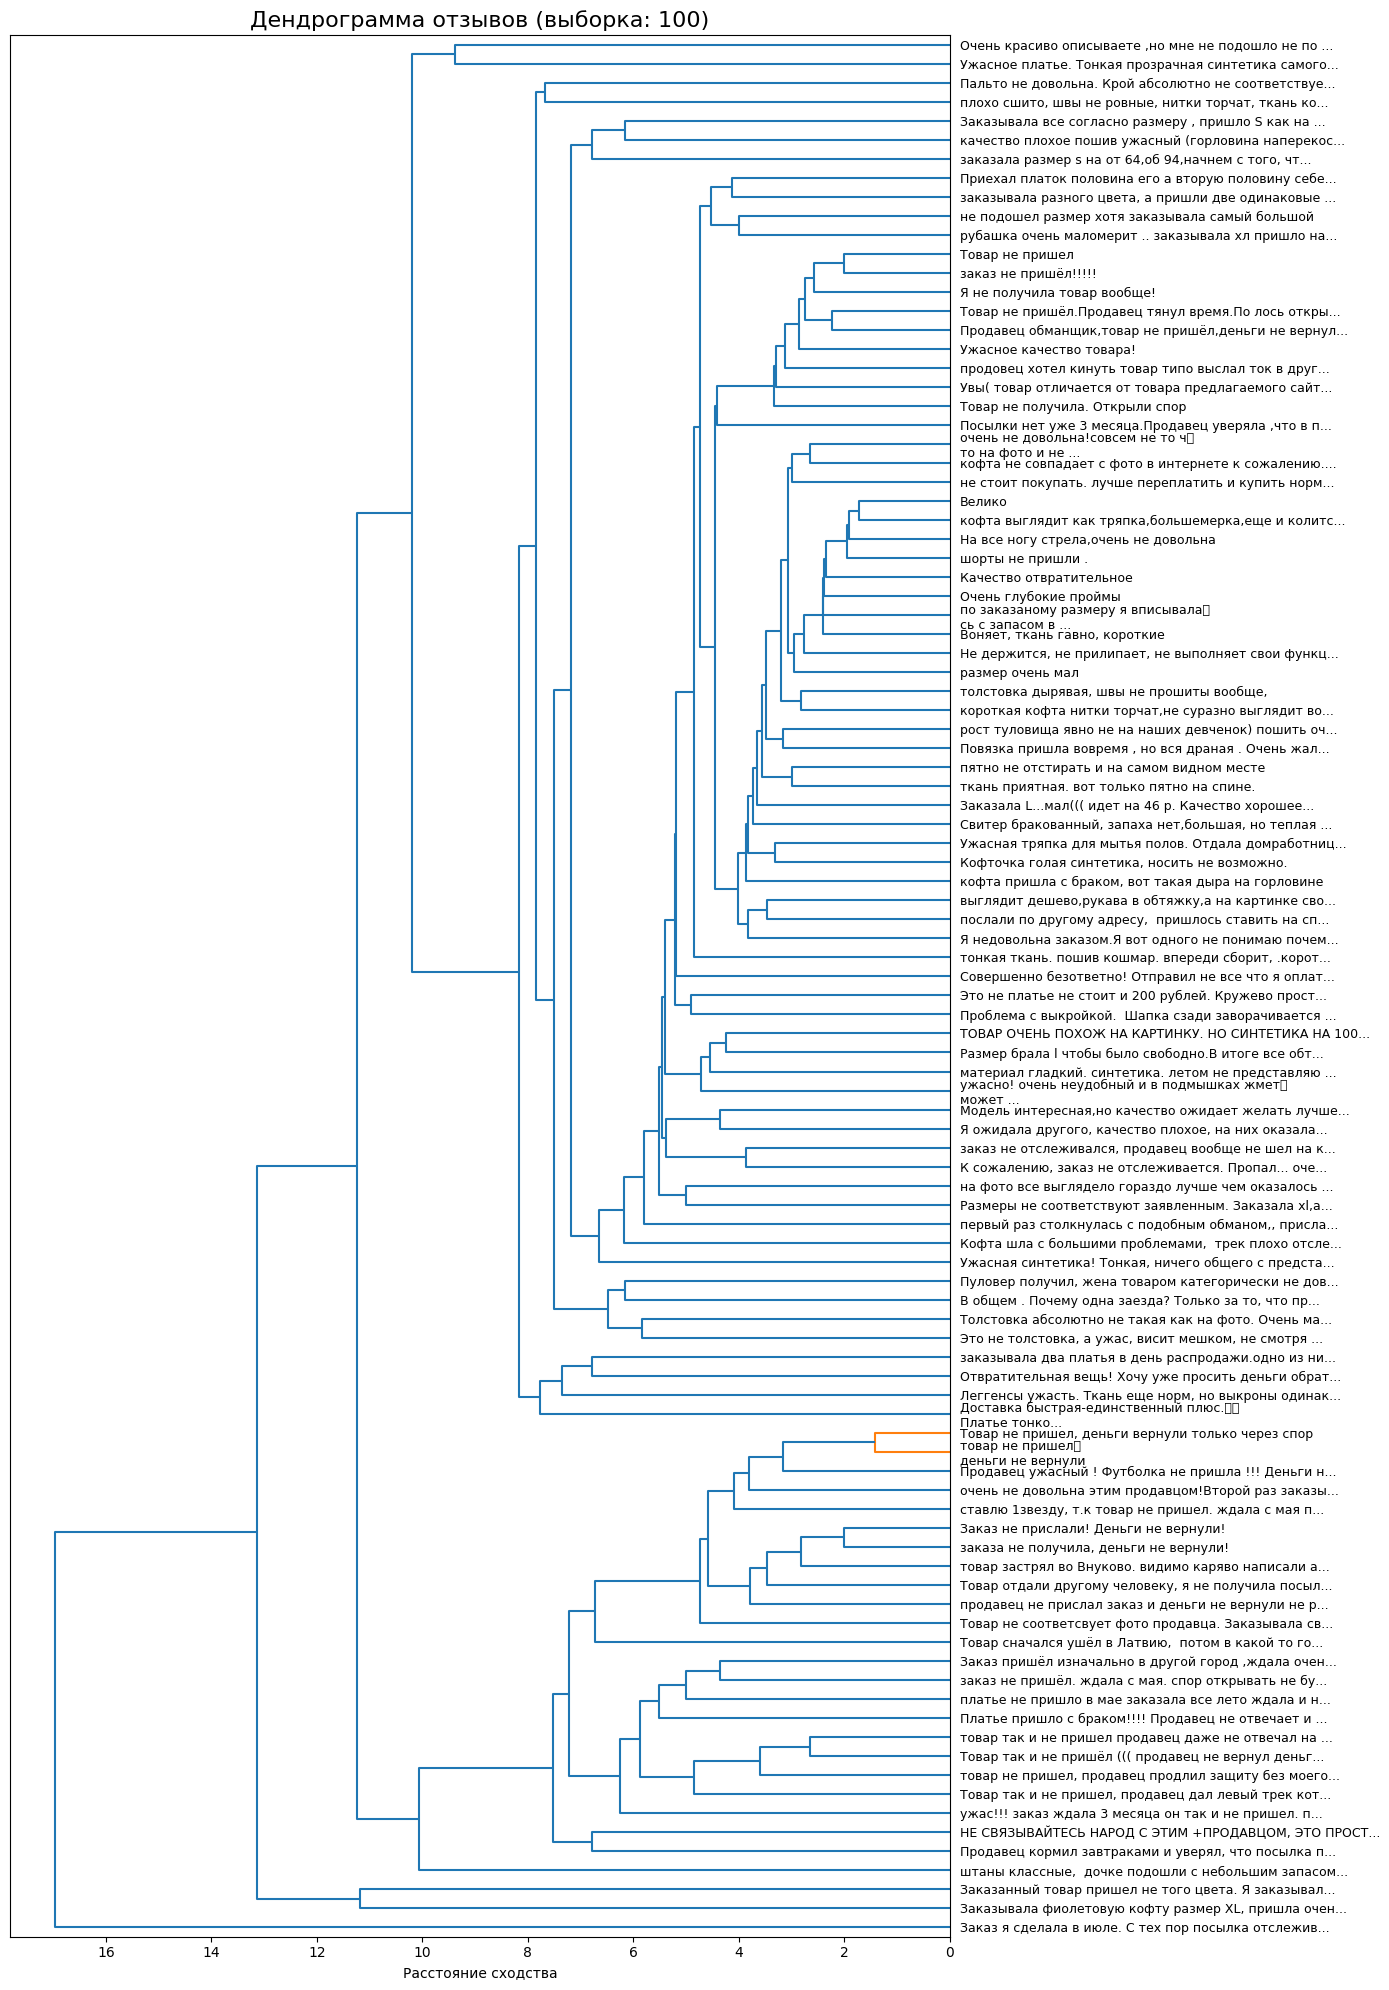

In [16]:
# Визуализация для небольшой выборки
sample_size = min(100, X.shape[0])
sample_indices = range(sample_size)

sample_vectors = X[:sample_size].toarray()
linkage_matrix = linkage(sample_vectors, method='ward')

labels_short = [
    (str(df.iloc[i]['review'])[:50] + '...') if len(str(df.iloc[i]['review'])) > 50
    else str(df.iloc[i]['review'])
    for i in sample_indices
]

plt.figure(figsize=(14, 20))
dendrogram(
    linkage_matrix,
    labels=labels_short,
    orientation='left',
    leaf_font_size=9,
    color_threshold=1.5
)
plt.title(f'Дендрограмма отзывов (выборка: {sample_size})', fontsize=16)
plt.xlabel('Расстояние сходства')
plt.tight_layout()
plt.show()